# ONI Correlation Maps


This notebook evaluates the spatial relationship between **surface** ocean variables and the **Oceanic Niño Index (ONI)** by calculating temporal correlation maps across the selected model simulations and observational products. It provides a configurable workflow for selecting variables, datasets, and analysis periods; loading and preparing the corresponding data; aligning them with the ONI time series; and mapping the resulting correlation patterns.


The correlation is always between anomalies relative to seasonal climatology and calculated in time. Positive and negative correlations indicate regions where the selected variable tends to vary in phase or out of phase with ONI, respectively.

The notebook follows four main stages:

1. **Package and configuration setup** – Load the required analysis, plotting, and project configuration utilities.
2. **Data request configuration** – Define the variables, datasets/experiments, temporal range, seasonal selection, depths, and ONI-related analysis options.
3. **Data loading and preparation** – Load and preprocess the requested fields, prepare the ONI time series, and align the data in time.
4. **Correlation analysis and visualization** – Calculate grid-point correlations with ONI and generate global or regional correlation maps for comparison across the selected datasets.


## Optional configurations

1. **`decompose_spco2`** – If both `spco2` and sea-surface temperature (`tos`) are available, surface \(pCO_2\) can be decomposed into its **temperature-driven** and **residual** components before calculating the ONI correlation.

2. **`vars_to_det`** – Selected variables can optionally be detrended before calculating their correlation with ONI.

   * Detrending can be performed using a trend fitted across the full time series or using **month-specific annual trends**.
   * **LOWESS (locally weighted scatterplot smoothing)** can also be used to estimate and remove nonlinear trends.



### Package and configuration setup

In [3]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(1, '/home/rpg002/BGC_skill')

from fnmatch import fnmatch
import pandas as pd
import Configs as configs
from prepare import (prepare_data_for_analysis, 
                    load_ONI,
                     calculate_climatology, 
                     calculate_detrended,
                     spco2_decomposition,
                     get_corr_ONI,
                     experiment_finder)

from Modules.plotting.module_plot_2D import *


In [4]:
units = configs.units
boundaries_dict = configs.boundaries_dict
model_lev_bounds = configs.model_lev_bounds
model_levels = configs.model_levels
unit_change_dics = configs.unit_change_dics
varx = configs.varx

### User configs

In [5]:
data_directory = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data'


assimilation_BGC_run_id = None
CanOE_assimilation_BGC_run_id = 1

var_list = [ 'spco2', 'chlos', 'thetao'] #,'talk','dissic', 'no3',  'silicate', 'po4']
experiment_list = ['observation','assimilation', 'historical']
model_list = ['CanESM5', 'CanESM5-CanOE']

 ## this could be a dictionary for each variable as they might have different sources or one source for all variables.
obs_source = {'spco2' : 'SOMFFN',
              'chlos' : 'ESACCI',
              'thetao' : 'SODA'} 

decompose_spco2: bool = False
vars_to_det: list[str] =  None #['spco2']

### Data Loading

In [6]:
dict_em_data, obs_mask, model_mask , mask_ocean_surface = prepare_data_for_analysis(var_list,
                            experiment_list,
                            model_list,
                            obs_source,
                            data_directory ,
                            unit_change_dics,
                            assimilation_BGC_run_id = None,
                            CanOE_assimilation_BGC_run_id = 1,
                            nldyr = 1, 
                            varx_dicts = varx,
                            verbose = True)


observation directories: 

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/observation/SOMFFN
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/observation/ESACCI
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/thetao/observation/SODA

model directories: 

spco2 assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/assimilation/CanESM5-CanOE_1
spco2 historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/historical/CanESM5-CanOE
chlos assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/assimilation/CanESM5-CanOE_1
chlos historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/historical/CanESM5
/space/hall7/sitestore/eccc/crd

In [7]:
ONI_dict = load_ONI(experiment_list, 
                    model_list, 
                    assimilation_BGC_run_id,
                    CanOE_assimilation_BGC_run_id,
                    obs_source='ERSST')

In [8]:
idisplay=False

if idisplay:

    ax = plt.subplot(1,1,1)
    ax.pcolormesh(mask_ocean_surface.lon, mask_ocean_surface.lat, mask_ocean_surface.where(mask_ocean_surface ==0).values, vmin = 0, vmax =1)
    plt.scatter(-50.5, 43.5, color='red', s=10, label='My Point', zorder=10)

In [9]:
idisplay=False

if idisplay:
    print('checking loaded data')
    for var in dict_em_data:
        for exp in dict_em_data[var]:
            print(f'{var} {exp}')
            display(dict_em_data[var][exp].data)




### Data Prep

In [10]:
if decompose_spco2:
    dict_em_data = spco2_decomposition(dict_em_data)

In [11]:
_, dict_em_anom = calculate_climatology(dict_em_data,
                                                   y0_base=None,
                                                   y1_base=None,
                                                   return_anomaly=True)

dict_corr_anom = get_corr_ONI(dict_em_anom, ONI_dict)

calculating spco2 CanESM5-CMOC_assimilation climatology over 1982 - 2022 ...
done.
calculating spco2 CanESM5-CanOE_1_assimilation climatology over 1982 - 2022 ...
done.
calculating spco2 CanESM5-CMOC_historical climatology over 1982 - 2022 ...
done.
calculating spco2 CanESM5-CanOE_historical climatology over 1982 - 2022 ...
done.
calculating spco2 obs climatology over 1982 - 2022 ...
done.
calculating chlos CanESM5-CMOC_assimilation climatology over 1998 - 2023 ...
done.
calculating chlos CanESM5-CanOE_1_assimilation climatology over 1998 - 2023 ...
done.
calculating chlos CanESM5-CMOC_historical climatology over 1998 - 2023 ...
done.
calculating chlos CanESM5-CanOE_historical climatology over 1998 - 2023 ...
done.
calculating chlos obs climatology over 1998 - 2023 ...
done.
calculating thetao CanESM5-CMOC_assimilation climatology over 1980 - 2023 ...
done.
calculating thetao CanESM5-CanOE_1_assimilation climatology over 1980 - 2023 ...
done.
calculating thetao CanESM5-CMOC_historical 

In [18]:
dict_em_det = calculate_detrended(dict_em_data,
                                  vars_to_det,
                                  month_specific_det=True
                                  )

if dict_em_det is not None:
    dict_corr_det = get_corr_ONI(dict_em_det, ONI_dict)

### Plots

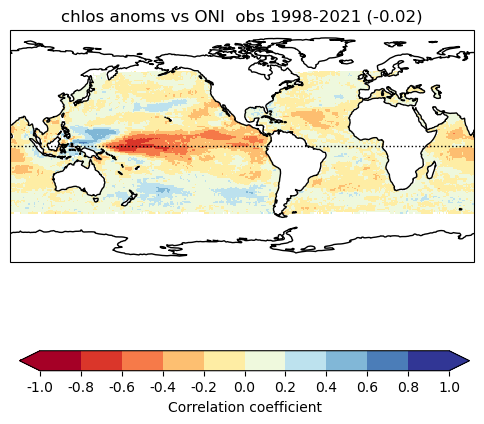

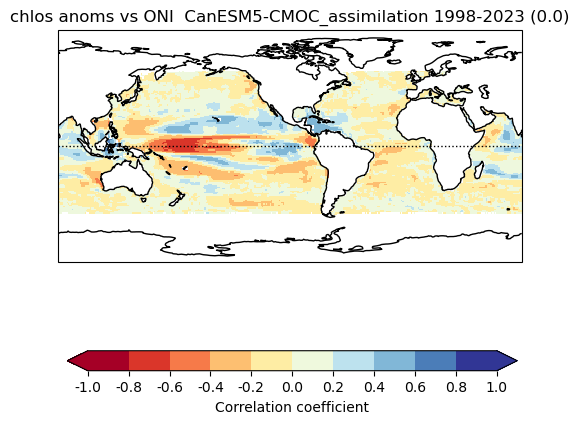

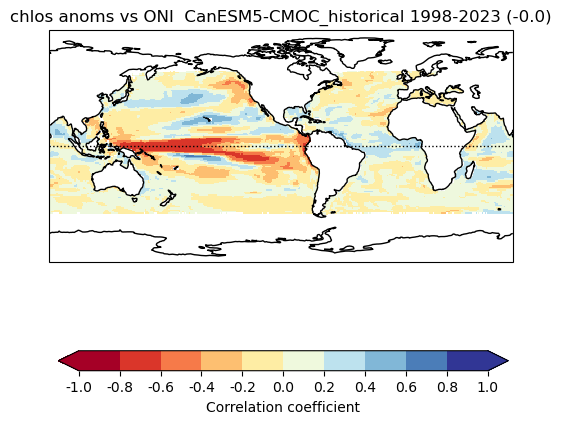

In [28]:
var = 'chlos'

model_experiment = ['observation', 'CanESM5 assimilation' , 'CanESM5 historical']

figsize = (5,5)

central_longitude = 260


datadict = dict_corr_anom[var]
ds_list = experiment_finder(datadict, model_experiment)

title = f'{var} anoms vs ONI '

plot_global_map(ds_list,
                    datadict,
                    figsize=figsize,                    
                    central_longitude=central_longitude,
                    cbar_label= 'Correlation coefficient',  
                    title = title,
                    show_equator=True,
                    cbar=True,
                    nval = 20)
